In [1]:
from configs import avail_models, get_avail_splits
from models import norm_vals
from video_dataset import (
    get_wlasl_info,
    get_data_set,
    DataSetInfo,
    VideoDataset,
    InstanceDict
    )
import utils
import configs
import torch
from torch.utils.data import DataLoader
from pathlib import Path
import video_transforms as vt
import torchvision.transforms.v2 as v2
from typing import (
    Tuple,
    Literal,
    cast,
    Any,
    Dict,
    List)
import torch
import torch.nn.functional as F
from testing import test_topk_clsrep
from models import get_model
import json
import tqdm
import numpy as np

In [2]:
configs.set_seed()

Performance Review:

In [3]:
import json
import pandas as pd

load_path = "performance_outliers.json"

# 1. Load the JSON data from the file
with open(load_path, "r") as f:
    loaded_data = json.load(f)

# 2. Convert the data back into Pandas DataFrames
loaded_over_df = pd.DataFrame(loaded_data["overachievers"])
loaded_under_df = pd.DataFrame(loaded_data["underachievers"])

print("Successfully loaded data back into DataFrames!")

# Display the first few rows to verify
print("\nRestored Overachievers:")
display(loaded_over_df.head())

print("\nRestored Underachievers:")
display(loaded_under_df.head())

Successfully loaded data back into DataFrames!

Restored Overachievers:


,Gloss,Instances,Signers,F1_Score
0,beginning,5,3,1.0
1,swimsuit,5,3,1.0



Restored Underachievers:


,Gloss,Instances,Signers,F1_Score
0,before,18,13,0.0
1,thin,15,13,0.0
2,eat,14,13,0.0
3,yellow,13,13,0.0
4,hot,15,12,0.0


## Setup

### Model

Available models:

In [4]:
av_models = avail_models()
for idx, m in enumerate(av_models):
    print(f"{idx}: {m}")

0: S3D
1: R3D_18
2: R(2+1)D_18
3: Swin3D_T
4: Swin3D_S
5: Swin3D_B
6: MViTv2_S
7: MViTv1_B


Chosen model: 

In [5]:
model_name = av_models[6]
print(model_name)

MViTv2_S


Norm values: 

In [6]:
model_info = norm_vals(model_name)
print(model_info)

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


### Dataset

Available splits

In [7]:
av_splits = get_avail_splits()
for s in av_splits:
    print(s)

asl100
asl2000
asl300
asl1000


Chosen split, and set

In [8]:
split_name = av_splits[1]
print(split_name)

asl2000


Dataset info

In [9]:

train_info = get_wlasl_info(split_name, set_name="train")
print(train_info)


{'root': PosixPath('../data/WLASL/WLASL2000'), 'labels': PosixPath('preprocessed/labels/asl2000'), 'label_suff': 'fixed_frange_bboxes_len.json', 'set_name': 'train'}


Class list

In [10]:
class_list = configs.get_class_list()
print(len(class_list))

2000


#### Data Sets

one with centre crop and one with bounding box crop and resize


In [11]:
norm_dict = norm_vals(model_name)
print(model_info)
num_frames = 16
frame_size = 224
batch_size = 1

{'mean': (0.45, 0.45, 0.45), 'std': (0.225, 0.225, 0.225)}


## Centre Crop

In [12]:
final_transform = v2.Compose(
    [
        v2.Lambda(vt._normalize_to_float),
        v2.Normalize(mean=norm_dict["mean"], std=norm_dict["std"]),
        v2.Lambda(vt._permute_time_channel),
        
    ]
)
cc_tranform = v2.Compose(
    [
        v2.CenterCrop(frame_size), final_transform
    ]
)
train_set = VideoDataset(
    set_info=train_info,
    num_frames=num_frames,
    transforms=cc_tranform,   
)

Dataloader

In [13]:
cc_loader = DataLoader(
    train_set, 
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


## Examine frames

In [14]:
def prep_next2(sample: dict[str, int | torch.Tensor]) -> tuple[torch.Tensor, int]:
    frames = sample['frames']
    assert isinstance(frames, torch.Tensor), f'frames is type: {type(frames)}'
    label_num = sample['label_num']
    assert isinstance(label_num, torch.Tensor), f'label num is type: {type(label_num)}'
    
    if len(frames.shape) == 5:
        frames = frames.squeeze(dim=0)
    if frames.shape[1] != 3: 
        frames = frames.permute(1, 0, 2, 3) #swap T and C
    return frames, int(label_num.squeeze())

# Looking at what the machine gets right


In [15]:
figsize = (2,2)

In [16]:
def gloss_iterator(dataloader: DataLoader, gloss_label: int):
    """Find all instances matching gloss label"""
    for sample in tqdm.tqdm(dataloader, desc="Searching"):
        if gloss_label == sample['label_num']:
            yield sample
    
def save_samples(dataloader: DataLoader, gloss_label: int, prefix: str = 'eda_performers') -> List[Any]:
    """Stash gloss instances for fast retrieval"""
    all_gloss_instances = [instance for instance in gloss_iterator(dataloader, gloss_label)]
    with open(prefix + f'_{gloss_label}.json', 'r') as f:
        json.dump(all_gloss_instances, f, indent=4)
    return all_gloss_instances

def load_samples(dataloader: DataLoader, gloss_label: int, prefix: str = 'eda_performers') -> List[Any]:
    save_path = Path(prefix + f'_{gloss_label}')
    try:
        with open(save_path, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        return save_samples(dataloader, gloss_label, prefix)
        

In [17]:

with open(configs.CLASSES_PATH, 'r') as f:
    classes = json.load(f)
    
clss_to_idx = {gloss: idx for idx, gloss in enumerate(classes)}


In [18]:
print("--- Overachieving Glosses ---")
for gloss in loaded_over_df['Gloss']:
    print(gloss)
    gloss_label = clss_to_idx[gloss]
    print(gloss_label)
    samples = load_samples(cc_loader, gloss_label)
    for sample_cc in samples:
        frames_cc, label_num = prep_next2(sample_cc)
        print(f"frames: {frames_cc.shape}")
        print(f'Class: {class_list[label_num]}')
        utils.plt_display_grid(frames_cc, num_frames, size=figsize)
    
    

--- Overachieving Glosses ---
beginning
1318


Searching: 100%|██████████| 14295/14295 [02:31<00:00, 94.08it/s] 


FileNotFoundError: [Errno 2] No such file or directory: 'eda_performers_1318.json'

# Looking at what the machine gets wrong

--- Underachieving Glosses ---
before
3


Searching:   0%|          | 67/14295 [00:00<02:35, 91.51it/s]

frames: torch.Size([16, 3, 224, 224])
Class: before


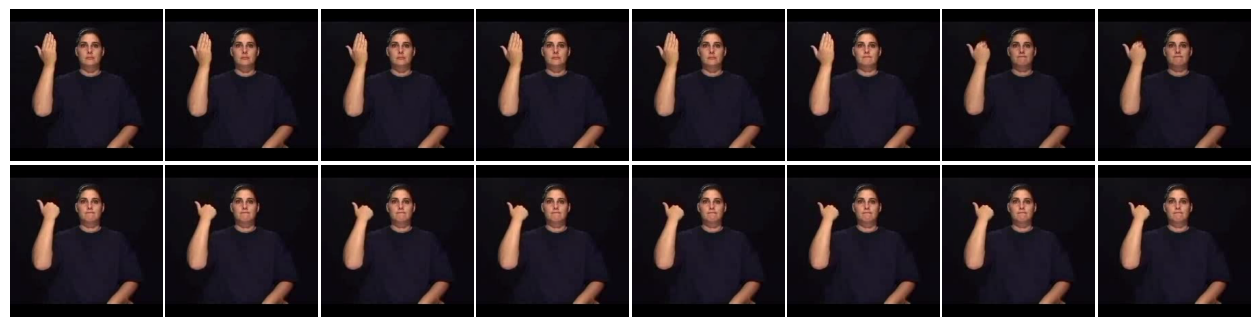

Searching:   1%|          | 75/14295 [00:00<03:09, 75.16it/s]


In [ ]:

print("--- Underachieving Glosses ---")
for gloss in loaded_under_df['Gloss']:
    print(gloss)
    gloss_label = clss_to_idx[gloss]
    samples = load_samples(cc_loader, gloss_label)
    for sample_cc in samples:
        frames_cc, label_num = prep_next2(sample_cc)
        print(f"frames: {frames_cc.shape}")
        print(f'Class: {class_list[label_num]}')
        utils.plt_display_grid(frames_cc, num_frames, size=figsize)
        break
    break

# Test to see what MVIT predicts for before

In [ ]:
import torch.nn.functional as F

def analyze_class_confidence(model, test_loader, target_class_idx, top_n=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    model.to(device)
    class_samples_data = []
    
    with torch.no_grad():
        for item in tqdm.tqdm(test_loader, desc="testing"):
            data, target = item["frames"], item["label_num"]
            data = data.to(device)
            
            # Get probabilities
            output = model(data)
            probs = F.softmax(output, dim=1)
            
            # Find samples in this batch belonging to our target class
            mask = (target == target_class_idx)
            if mask.any():
                # Extract the probabilities and IDs for the target class samples
                target_probs = probs[mask].cpu().numpy()
                v_ids = np.array(item['video_id'])[mask.cpu().numpy()]
                
                for i in range(len(target_probs)):
                    class_samples_data.append({
                        "video_id": v_ids[i],
                        "probs": target_probs[i],
                        "conf": target_probs[i][target_class_idx] # Confidence in correct class
                    })

    # Sort samples by confidence (highest to lowest)
    class_samples_data.sort(key=lambda x: x['conf'], reverse=True)

    print(f"Top {top_n} Most Confident Correct Predictions for Class {target_class_idx}:")
    for sample in class_samples_data[:top_n]:
        top_k_indices = np.argsort(sample['probs'])[-3:][::-1]
        print(f"ID: {sample['video_id']} | Target Conf: {sample['conf']:.4f} | Top 3 Preds: {top_k_indices}")

    return class_samples_data


In [ ]:
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

In [ ]:
model = get_model(model_name, train_set.num_classes, drop_p=0.5)
exps_dict_path = Path('./results/wlasl_saicist.json')
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)

runs_dir = Path('./runs') / split_name
checkpoint_path = runs_dir / f'{model_name}_exp{exps_dict[split_name][model_name][0]}' / 'checkpoints' / 'best.pth'
print(checkpoint_path)
checkpoint = torch.load(checkpoint_path)

for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)
print(exps_dict[split_name][model_name])
model.load_state_dict(checkpoint)

/home/luke/miniconda3/envs/wlasl/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


runs/asl2000/MViTv2_S_exp000/checkpoints/best.pth


/tmp/ipykernel_2825316/2771926997.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


['000']


<All keys matched successfully>

In [ ]:
# Example Usage:
confidence_data = analyze_class_confidence(model, cc_loader, target_class_idx=12)

testing:   0%|          | 0/14295 [00:00<?, ?it/s]

testing:   2%|▏         | 231/14295 [00:14<14:42, 15.93it/s]


KeyError: 'video_id'